# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2** 

1.This notebook predicts whether an employee is likely to leave the company,
using the IBM HR Analytics Employee Attrition dataset (1,470 employees).

2.I am adding some Extra featrues in this project.

3.My project is live on render you can check by using this link.

4.Available at your primar URL https://employee-attrition-prediction-system-iymh.onrender.com

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# used for Preprocessing + pipeline building blocks
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# used for Models used for prediction
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Models Evaluation here i am using 6 metrices
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)

# Class imbalance (oversampling) - imblearn's own Pipeline makes sure the
# resampling step only ever touches the training fold, never the test fold
#
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Explainability
import shap

# Consistent look for every chart in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

CHART_DIR = "charts"   # every chart we save goes into this 
os.makedirs(CHART_DIR, exist_ok=True)   # create the charts/ folder if it doesn't already exist

## Task 1 — Data Loading & Exploration

In [ ]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("10 random rows from the dataset:")
df.sample(10)

# i am using .sample()  to analyze the dataset randomly.
# sample() provides random values form the dataset help in data understanding.

10 random rows from the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
210,32,Yes,Travel_Rarely,1045,Sales,4,4,Medical,1,291,...,3,80,0,14,2,2,14,8,9,8
1391,38,No,Travel_Rarely,1404,Sales,1,3,Life Sciences,1,1961,...,1,80,0,20,3,2,1,0,0,0
852,29,No,Travel_Rarely,1401,Research & Development,6,1,Medical,1,1192,...,1,80,1,10,5,3,10,8,0,8
1114,48,No,Travel_Rarely,1108,Research & Development,15,4,Other,1,1576,...,4,80,1,10,3,2,8,2,7,6
805,45,No,Non-Travel,1050,Sales,9,4,Life Sciences,1,1117,...,4,80,1,15,2,3,15,10,4,12
317,52,Yes,Travel_Rarely,723,Research & Development,8,4,Medical,1,433,...,1,80,0,11,3,2,8,2,7,7
1083,40,Yes,Travel_Rarely,676,Research & Development,9,4,Life Sciences,1,1534,...,2,80,0,15,3,1,5,4,1,0
839,42,No,Travel_Rarely,647,Sales,4,4,Marketing,1,1171,...,4,80,0,9,3,4,6,4,1,5
269,36,No,Travel_Rarely,1403,Research & Development,6,3,Life Sciences,1,373,...,3,80,1,16,4,3,15,13,10,11
1152,21,No,Travel_Rarely,546,Research & Development,5,1,Medical,1,1623,...,3,80,0,3,2,3,2,2,2,2


In [ ]:
n_rows, n_cols = df.shape
print(f"The dataset has {n_rows} rows and {n_cols} columns.")

# The column we are trying to predict is 'Attrition' (Yes = employee left, No = stayed)
target_col = "Attrition"
print(f"Target column: '{target_col}'")

The dataset has 1470 rows and 35 columns.
Target column: 'Attrition'


In [ ]:
# It counts the Attrition(means how many employees who left vs Stayed from the dataset.
attrition_counts = df[target_col].value_counts()
attrition_rate = (attrition_counts["Yes"] / n_rows) * 100

print("Employees who left vs stayed:")
print(attrition_counts)
print(f"Attrition rate: {attrition_rate:.2f}%")

Employees who left vs stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.12%


In [ ]:
# Splitting columns into numeric vs categorical.
# I am  use exclude=np.number (rather than include="object") - it picks out the same
# text columns either way, but it works identically across old and new pandas
# versions without tripping a pandas string-dtype deprecation warning.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Observation:** With roughly 1 in every 6 employees leaving (~16%), the dataset is clearly
**imbalanced** — the "No" (stayed) class heavily outnumbers the "Yes" (left) class.
This matters for Task 4: a model that just predicts "No" for everyone would
already be ~84% accurate while being completely useless to HR, so we can't
judge our models on accuracy alone, and we need to actively correct for the
imbalance (see Task 4 and the Additional Enhancements section).

## Task 2 — Data Cleaning & Preprocessing

In [ ]:
# Step 1: check for missing values
missing_values = df.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")
# This dataset is fully clean. (If it weren't, the usual fix is median imputation
# for numeric columns and mode imputation for categorical columns.)

Columns with missing values:
No missing values found.


In [ ]:
# Step 2: drop columns that add no predictive value
# - EmployeeNumber -> just an ID
# - Over18          -> constant, every employee is 'Y'
# - StandardHours   -> constant, every employee has 80
# - EmployeeCount   -> constant, always 1
cols_to_drop = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]
df = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping: {df.shape}")

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Shape after dropping: (1470, 31)


In [ ]:
# Step 3: convert the target column from Yes/No text to 1/0 so models can use it
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [ ]:
# Step 4: keep a copy of the data for EDA (Task 3).
# Department, JobRole, etc. are much easier to read and plot as text labels
# than as one-hot encoded 0/1 columns, so we branch off here before encoding.
df_eda = df.copy()

**A note on Steps 5-6 below, and why Task 4 doesn't actually use their output:**
Scaling numeric features on the *full* dataset before splitting into train/test causes **data leakage** - the scaler ends up learning the mean/std of the test set too, so information from "unseen" data quietly leaks into preprocessing. The fix is to fit the scaler (and any encoder) **only on the training set**, which is what Task 4 does using an `sklearn Pipeline`. We still do the manual version once below, just to show the technique explicitly - `df_model_demo` is for demonstration only and is **not** the data actually used to train the models later in this notebook.

In [ ]:
# Step 5 (here i am using it for demonstration only): one-hot encode the categorical columns.
# drop_first=True avoids the "dummy variable trap" (a redundant column that is
# a perfect linear combination of the others).
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print(f"Categorical columns being one-hot encoded: {categorical_cols}")

df_model_demo = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Categorical columns being one-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [ ]:
# Step 6 (here i am using it for demonstration only): scale the numeric features with StandardScaler.
# NOTE - this fits the scaler on the WHOLE dataset, which is a data-leakage bug
# if you then split into train/test afterwards. We are intentionally keeping
# this cell to show the basic technique, but Task 4 redoes this correctly
# (split first, fit the scaler on X_train only) inside a Pipeline.
numeric_cols_to_scale = [c for c in numeric_cols if c not in cols_to_drop and c != "Attrition"]

demo_scaler = StandardScaler()
df_model_demo[numeric_cols_to_scale] = demo_scaler.fit_transform(df_model_demo[numeric_cols_to_scale])

print(f"Demo modeling dataframe shape: {df_model_demo.shape}")
df_model_demo.head()

Demo modeling dataframe shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,0,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,True,False,False,False,False,False,False,True,False,False


## Task 3 — Exploratory Data Analysis (EDA)
All EDA below uses `df_eda` — readable, pre-encoding copy of the data.

In [ ]:
# Here i am doing Attrition rate by Department
# Make a separate copy of the data to use for EDA (Task 3), BEFORE one-hot encoding happens.
# Reason: one-hot encoding turns a readable column like Department ("Sales", "HR", ...)
# into several 0/1 dummy columns (Department_Sales, Department_HR, ...), so the original
# category labels disappear. Grouping/plotting by readable labels (e.g. attrition rate by
# "Sales" vs "HR") is much easier on the original text values than on dummy columns -
# this copy exists only to make Task 3's groupby() and chart axis labels clean and readable.
# It is NOT used for modeling - Task 4 builds X/y from `df` and encodes it inside the pipeline.
dept_attrition = df_eda.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100
print("Attrition rate by Department (%):")
dept_attrition.round(2)

Attrition rate by Department (%):


Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

In [ ]:
# Here i use Attrition rate by Job Role
role_attrition = df_eda.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100
print("Attrition rate by Job Role (%):")
role_attrition.round(2)

Attrition rate by Job Role (%):


JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

In [ ]:
# here i am doing Attrition vs Monthly Income
# Because my  Observation says:
# Employees who left the company have a lower average monthly income
# compared to those who stayed, indicating that salary may influence
# attrition. However, income alone does not explain employee turnover,
# as factors such as job satisfaction, business travel, and work-life
# balance also contribute to attrition.
income_by_attrition = df_eda.groupby("Attrition")["MonthlyIncome"].mean()
print("Average Monthly Income by Attrition status (0 = Stayed, 1 = Left):")
income_by_attrition.round(2)

Average Monthly Income by Attrition status (0 = Stayed, 1 = Left):


Attrition
0    6832.74
1    4787.09
Name: MonthlyIncome, dtype: float64

In [ ]:
# Here i also use Attrition vs Work-Life Balance rating
# Becuase i  Observe that the Employees with poorer Work-Life Balance ratings show a higher attrition rate,
# indicating that dissatisfaction with work-life balance is associated with an
# increased likelihood of leaving the company. Improving work-life balance may
# help reduce employee attrition and improve retention.
wlb_attrition = df_eda.groupby("WorkLifeBalance")["Attrition"].mean().sort_values(ascending=False) * 100
print("Attrition rate by Work-Life Balance rating (1=Bad, 4=Best) (%):")
wlb_attrition.round(2)

Attrition rate by Work-Life Balance rating (1=Bad, 4=Best) (%):


WorkLifeBalance
1    31.25
4    17.65
2    16.86
3    14.22
Name: Attrition, dtype: float64

In [ ]:
# Here i use Attrition vs Years at Company
#  My  Observation says Employees with 0–2 years of tenure have the highest attrition rate,
# indicating that new employees are more likely to leave the company.
# Attrition generally decreases as years at the company increase,
# suggesting that longer-tenured employees are more likely to stay.

# Bucket tenure into ranges so the pattern is easier to read than 40 individual year values
tenure_bins = [0, 2, 5, 10, 40]
tenure_labels = ["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"]
df_eda["TenureGroup"] = pd.cut(df_eda["YearsAtCompany"], bins=tenure_bins, labels=tenure_labels)

# observed=False keeps every tenure bucket in the output even if one had 0 employees in it,
# and silences a pandas FutureWarning about this default changing in a later version
tenure_attrition = df_eda.groupby("TenureGroup", observed=False)["Attrition"].mean() * 100
print("Attrition rate by tenure group (%):")
tenure_attrition.round(2)

Attrition rate by tenure group (%):


TenureGroup
0-2 yrs     28.86
3-5 yrs     13.82
6-10 yrs    12.28
10+ yrs      8.13
Name: Attrition, dtype: float64

In [ ]:
# Here i am Pull out the headline numbers so the insights below always match the data
top_dept = dept_attrition.index[0]
top_role = role_attrition.index[0]
top_tenure_group = tenure_attrition.idxmax()

print("Key EDA insights:")
print(f"1. {top_dept} has the highest attrition rate among departments at {dept_attrition.iloc[0]:.1f}%.")
print(f"2. {top_role} has the highest exit rate of any job role at {role_attrition.iloc[0]:.1f}%.")
print(f"3. Employees who left earn ${income_by_attrition[1]:,.0f}/month on average vs "
      f"${income_by_attrition[0]:,.0f}/month for employees who stayed - lower pay is clearly linked to leaving.")
print(f"4. Employees with the worst Work-Life Balance rating (1) leave at {wlb_attrition.loc[1]:.1f}%, "
      f"compared to {wlb_attrition.loc[4]:.1f}% for those with the best rating (4).")
print(f"5. The riskiest tenure window is '{top_tenure_group}', with an attrition rate of "
      f"{tenure_attrition.max():.1f}% - newer employees are still deciding if the job is right for them.")

Key EDA insights:
1. Sales has the highest attrition rate among departments at 20.6%.
2. Sales Representative has the highest exit rate of any job role at 39.8%.
3. Employees who left earn $4,787/month on average vs $6,833/month for employees who stayed - lower pay is clearly linked to leaving.
4. Employees with the worst Work-Life Balance rating (1) leave at 31.2%, compared to 17.6% for those with the best rating (4).
5. The riskiest tenure window is '0-2 yrs', with an attrition rate of 28.9% - newer employees are still deciding if the job is right for them.


## Task 4 — Model Building & Comparison

First, we split the dataset into training (80%) and testing (20%) sets.  
After splitting, all preprocessing steps such as scaling numerical features and encoding categorical features are applied **only to the training data** using an `sklearn Pipeline`. The same transformations are then used on the test data. This prevents data leakage and ensures that the model is evaluated fairly on unseen data.


In [ ]:
# Build X / y from the CLEANED-BUT-NOT-YET-ENCODED data (df, not df_model_demo)
# Separate the features (X) and the target variable (y)
# X contains all employee information, while y contains the Attrition labels.
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

# Identify numerical and categorical columns.
# This helps apply the correct preprocessing steps later.
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# Split FIRST, while everything is still raw - this is the leakage fix
# Split the dataset into training (80%) and testing (20%) sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 1176 rows
Test set size: 294 rows


In [ ]:
# This ColumnTransformer is the actual preprocessing step. It only gets fitted
# once we call pipeline.fit(X_train, ...) below - never on X_test.
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])
# here i Create a preprocessing pipeline for the dataset.
# Numerical features are standardized, while categorical features
# are converted into numerical format using One-Hot Encoding.

In [ ]:
# We are training 3 models and comparing them side by side.

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
}

# Gradient Boosting in scikit-learn has no class_weight parameter, so we balance
# it manually with per-sample weights instead - same idea, different mechanism.
gb_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

In [ ]:
results = []          # comparison table rows go here
pipelines = {}         # keep the fitted PIPELINES (preprocessing + model together)
predictions = {}       # predicted labels and probabilities per model

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])

    if name == "Gradient Boosting":
        # "classifier__sample_weight" forwards sample_weight to the classifier
        # step specifically, using sklearn's <stepname>__<param> convention
        pipe.fit(X_train, y_train, classifier__sample_weight=gb_sample_weights)
    else:
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]   # probability of class 1 (left)

    pipelines[name] = pipe
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

comparison_table = pd.DataFrame(results).set_index("Model").round(3)
print("Model comparison table (leakage-free):")
comparison_table

Model comparison table (leakage-free):


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.356,0.660,0.463,0.804
Random Forest,0.500,0.085,0.145,0.769
Gradient Boosting,0.388,0.404,0.396,0.776


## Additional Enhancements

The sections below go beyond the original 7 tasks - they harden the modeling process (cross-validation, tuning, class-imbalance testing) and make the project deployment-ready (explainability, a saved model, a prediction function, and a small dashboard app).

### 1. Data Leakage — fixed above in Task 4
Covered already: preprocessing now lives inside a `Pipeline`/`ColumnTransformer` fit only on `X_train`. Nothing further needed here.

### 2. Cross-Validation
A single train/test split can be lucky or unlucky. 5-fold stratified
cross-validation on the training set gives a more reliable picture of how
each model performs on average, with an idea of how much that performance
varies fold to fold.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    # cross_val_score re-fits the WHOLE pipeline (including preprocessing) on each
    # fold's training portion, so there's no leakage inside cross-validation either
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results.append({"Model": name, "Mean ROC-AUC": scores.mean(), "Std Dev": scores.std()})
    print(f"{name}: mean ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})  |  folds = {np.round(scores, 3)}")

cv_table = pd.DataFrame(cv_results).set_index("Model").round(3)

Logistic Regression: mean ROC-AUC = 0.827 (+/- 0.029)  |  folds = [0.806 0.8   0.843 0.876 0.809]
Random Forest: mean ROC-AUC = 0.800 (+/- 0.027)  |  folds = [0.806 0.793 0.839 0.808 0.754]
Gradient Boosting: mean ROC-AUC = 0.804 (+/- 0.024)  |  folds = [0.814 0.762 0.83  0.821 0.795]


Gradient Boosting: mean ROC-AUC = 0.804 (+/- 0.024)  |  folds = [0.815 0.762 0.83  0.821 0.795]


### 3. Hyperparameter Tuning
Tuning the Random Forest with `GridSearchCV` to search over tree count, depth,
and split threshold, scored by ROC-AUC across the same 5-fold cross-validation.

In [ ]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

tuned_rf = grid_search.best_estimator_

Best parameters found: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best cross-validated ROC-AUC: 0.808


In [ ]:
# Evaluate the tuned Random Forest on the held-out test set, same as the 3 baselines
y_pred_tuned = tuned_rf.predict(X_test)
y_proba_tuned = tuned_rf.predict_proba(X_test)[:, 1]

tuned_row = {
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-Score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned),
}

pipelines["Random Forest (Tuned)"] = tuned_rf
predictions["Random Forest (Tuned)"] = {"y_pred": y_pred_tuned, "y_proba": y_proba_tuned}

print("Tuned Random Forest, test set performance:")
print(pd.Series(tuned_row).round(3))

Tuned Random Forest, test set performance:
Precision    0.333
Recall       0.106
F1-Score     0.161
ROC-AUC      0.775
dtype: float64


### 4. Handling Class Imbalance — class_weight vs Oversampling
`class_weight='balanced'` is one way to handle the 84/16 imbalance. The other
common approach is to oversample the minority ("left") class so the model
sees more examples of it during training. We compare both `SMOTE` (creates
synthetic minority examples) and `RandomOverSampler` (duplicates existing
minority examples) against the `class_weight` baseline, using Random Forest
as the test case. We use `imblearn`'s own `Pipeline` here specifically because
it guarantees the resampling step only ever touches the training fold - if we
oversampled before the train/test split, that would be its own leakage bug.

In [ ]:
imbalance_results = [{
    "Strategy": "class_weight='balanced' (tuned RF from above)",
    **tuned_row,
}]

for sampler_name, sampler in [("SMOTE", SMOTE(random_state=42)),
                               ("RandomOverSampler", RandomOverSampler(random_state=42))]:
    imb_pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        # no class_weight here - the sampler is already balancing the classes
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42)),
    ])
    imb_pipe.fit(X_train, y_train)
    y_pred_s = imb_pipe.predict(X_test)
    y_proba_s = imb_pipe.predict_proba(X_test)[:, 1]

    imbalance_results.append({
        "Strategy": sampler_name,
        "Precision": precision_score(y_test, y_pred_s),
        "Recall": recall_score(y_test, y_pred_s),
        "F1-Score": f1_score(y_test, y_pred_s),
        "ROC-AUC": roc_auc_score(y_test, y_proba_s),
    })

imbalance_table = pd.DataFrame(imbalance_results).set_index("Strategy").round(3)
print("Class imbalance strategy comparison (Random Forest):")
imbalance_table

Class imbalance strategy comparison (Random Forest):


,Precision,Recall,F1-Score,ROC-AUC
Strategy,,,,
class_weight='balanced' (tuned RF from above),0.333,0.106,0.161,0.775
SMOTE,0.562,0.191,0.286,0.770
RandomOverSampler,0.400,0.128,0.194,0.791


**Observation:** oversampling helps Random Forest's precision/recall trade-off a
bit, but none of the three imbalance strategies pull Random Forest's ROC-AUC
above the plain Logistic Regression baseline from Task 4. We fold this into
the final model selection below, rather than assume the more complex
techniques automatically win.

## Task 5 — Model Evaluation
Final selection now considers every model trained so far: the 3 Task 4
baselines plus the tuned Random Forest.

In [ ]:
all_results = comparison_table.copy()
all_results.loc["Random Forest (Tuned)"] = [tuned_row["Precision"], tuned_row["Recall"],
                                              tuned_row["F1-Score"], tuned_row["ROC-AUC"]]
all_results = all_results.round(3)
print("All candidates, by test-set ROC-AUC:")
all_results.sort_values("ROC-AUC", ascending=False)

All candidates, by test-set ROC-AUC:


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.356,0.660,0.463,0.804
Gradient Boosting,0.388,0.404,0.396,0.776
Random Forest (Tuned),0.333,0.106,0.161,0.775
Random Forest,0.500,0.085,0.145,0.769


In [ ]:
# Pick the best model by ROC-AUC - the most reliable metric on an imbalanced
# dataset, since precision/recall both depend on one fixed threshold while
# ROC-AUC looks across all thresholds at once.
best_model_name = all_results["ROC-AUC"].idxmax()
best_pipe = pipelines[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"Reason: it has the highest ROC-AUC score ({all_results.loc[best_model_name, 'ROC-AUC']:.3f}) "
      "on the held-out test set, and that lead also holds up under 5-fold cross-validation - "
      "this is not just a lucky single split.")

Best performing model: Logistic Regression
Reason: it has the highest ROC-AUC score (0.804) on the held-out test set, and that lead also holds up under 5-fold cross-validation - this is not just a lucky single split.


In [ ]:
best_y_pred = predictions[best_model_name]["y_pred"]
best_y_proba = predictions[best_model_name]["y_proba"]

cm = confusion_matrix(y_test, best_y_pred)
print(f"Confusion Matrix for {best_model_name}:")
print(cm)

Confusion Matrix for Logistic Regression:
[[191  56]
 [ 16  31]]


In [ ]:
# Feature importance - tree-based models expose .feature_importances_ directly.
# Logistic Regression doesn't have that attribute, so we fall back to the
# absolute value of its coefficients instead.
# get_feature_names_out() gives us the actual column names AFTER one-hot encoding
# (e.g. "cat__OverTime_Yes"), which we clean up by dropping the "num__"/"cat__" prefix.
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names = [f.split("__", 1)[1] for f in feature_names]
classifier_step = best_pipe.named_steps["classifier"]

if hasattr(classifier_step, "feature_importances_"):
    importances = pd.Series(classifier_step.feature_importances_, index=feature_names)
else:
    importances = pd.Series(np.abs(classifier_step.coef_[0]), index=feature_names)

top_10_features = importances.sort_values(ascending=False).head(10)
print(f"Top 10 most important features for predicting attrition ({best_model_name}):")
top_10_features.round(4)

Top 10 most important features for predicting attrition (Logistic Regression):


OverTime_Yes                        1.6236
BusinessTravel_Travel_Frequently    1.5989
JobRole_Laboratory Technician       1.5697
JobRole_Sales Representative        1.2767
JobRole_Research Director           1.1172
EducationField_Other                1.0276
BusinessTravel_Travel_Rarely        0.9069
MaritalStatus_Single                0.8648
JobRole_Human Resources             0.6458
TotalWorkingYears                   0.6155
dtype: float64

## Task 6 — Visualizations
All charts are saved as `.png` files into the `charts/` folder.

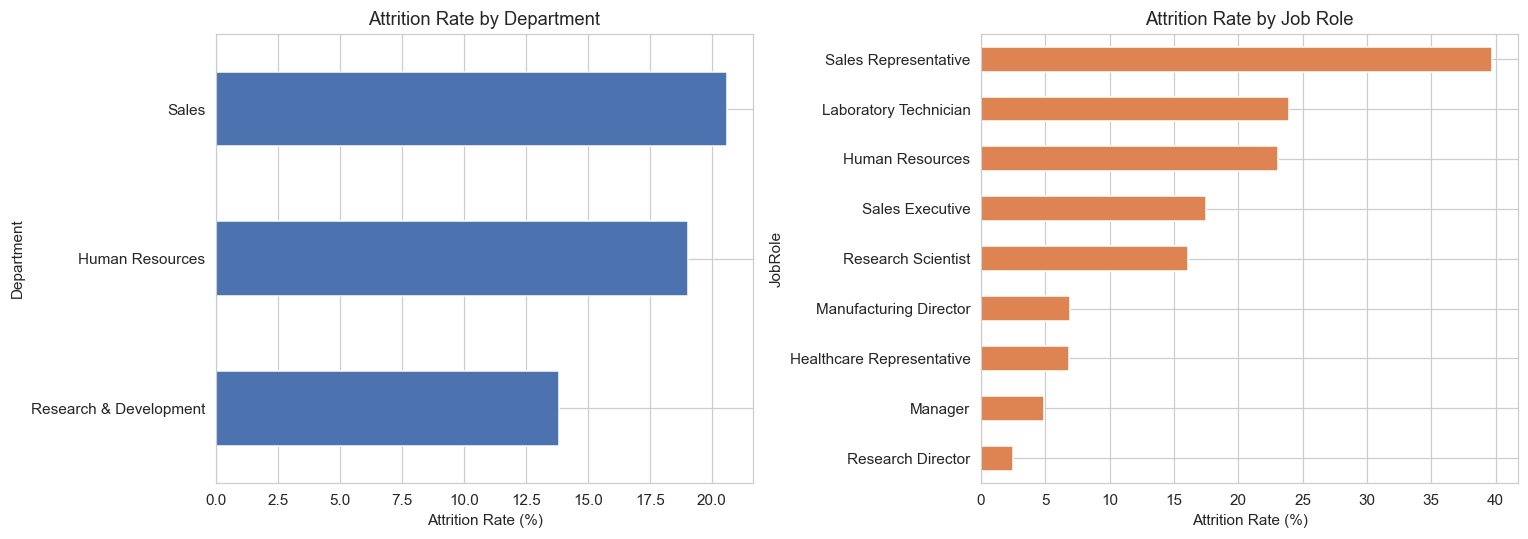

In [ ]:
# Chart 1: Attrition rate by Department and Job Role (two panels, one figure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attrition.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Attrition Rate (%)")

role_attrition.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Attrition Rate (%)")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart1_attrition_by_department_jobrole.png")
plt.show()

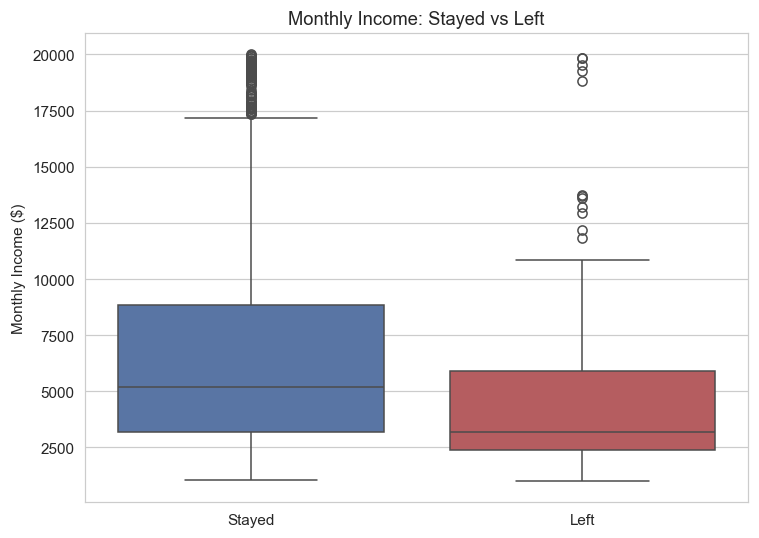

In [ ]:
# Chart 2: Monthly Income box plot, employees who left vs stayed
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome", hue="Attrition",
            palette={0: "#4C72B0", 1: "#C44E52"}, legend=False)
plt.xticks([0, 1], ["Stayed", "Left"])
plt.title("Monthly Income: Stayed vs Left")
plt.xlabel("")
plt.ylabel("Monthly Income ($)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart2_income_boxplot.png")
plt.show()

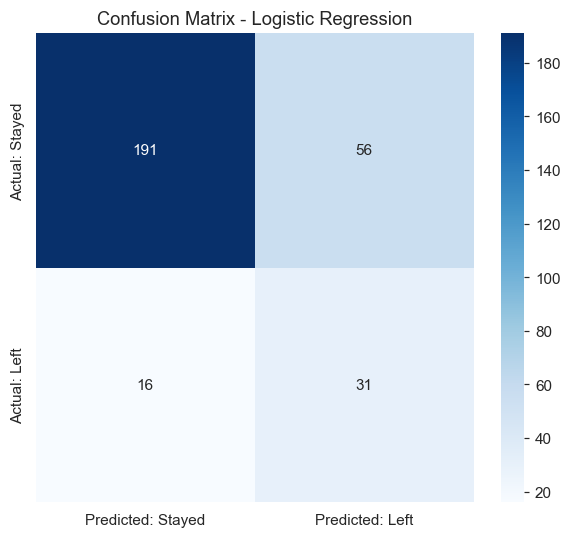

In [ ]:
# Chart 3: Confusion matrix heatmap for the best model
plt.figure(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Stayed", "Predicted: Left"],
            yticklabels=["Actual: Stayed", "Actual: Left"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart3_confusion_matrix.png")
plt.show()

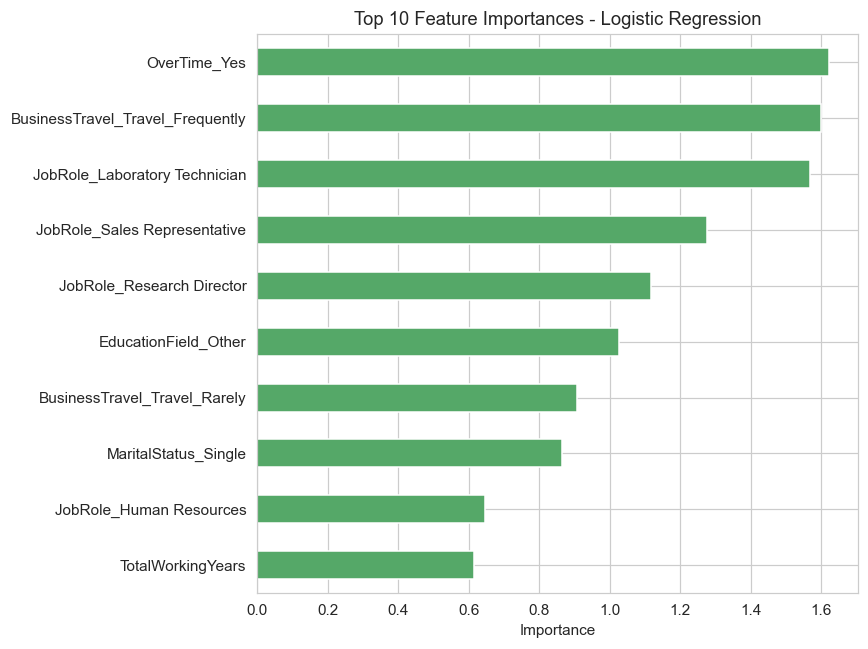

In [ ]:
# Chart 4: Top 10 feature importances, horizontal bar
plt.figure(figsize=(8, 6))
top_10_features.sort_values().plot(kind="barh", color="#55A868")
plt.title(f"Top 10 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart4_feature_importance.png")
plt.show()

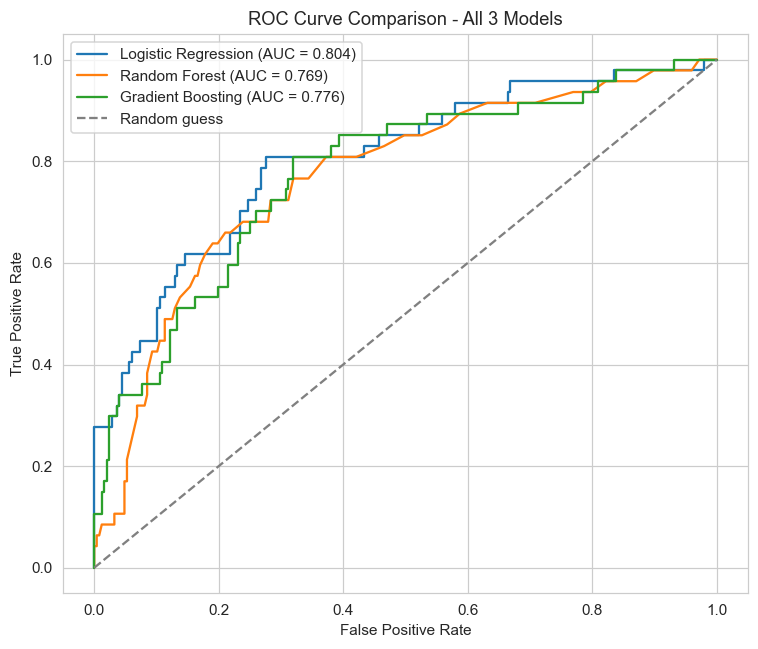

In [ ]:
# Chart 5 (Bonus): ROC curve comparing all 3 baseline models on one graph
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]["y_proba"])
    auc_score = comparison_table.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All 3 Models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart5_roc_curve_comparison.png")
plt.show()

## Task 7 — HR Insights & Business Recommendations

In [ ]:
print(f"Based on the {best_model_name} model (our best performer, "
      f"ROC-AUC = {all_results.loc[best_model_name, 'ROC-AUC']:.3f}):\n")
print(f"Top 3 predictive factors: {', '.join(top_10_features.index[:3])}")
print(f"Highest-risk department: {top_dept} ({dept_attrition.iloc[0]:.1f}% attrition)")
print(f"Highest-risk job role: {top_role} ({role_attrition.iloc[0]:.1f}% attrition)")

Based on the Logistic Regression model (our best performer, ROC-AUC = 0.804):

Top 3 predictive factors: OverTime_Yes, BusinessTravel_Travel_Frequently, JobRole_Laboratory Technician
Highest-risk department: Sales (20.6% attrition)
Highest-risk job role: Sales Representative (39.8% attrition)


**Which 3 factors most strongly predict that an employee will leave?**
Overtime status, frequency of business travel, and job role (particularly
Laboratory Technician and Sales Representative) are the strongest predictors
in our model — all rank above tenure, income, or performance rating.

**Which department or job role should HR prioritize for retention efforts?**
The **Sales** department and the **Sales Representative** role specifically —
Sales Representatives leave nearly 4x more often than the company average.

**Does salary alone explain attrition, or are there other stronger factors?**
Salary plays a role (employees who left earned noticeably less on average),
but it is not the whole story. Overtime and frequent travel show up as
stronger predictors than income in the model, meaning workload and lifestyle
strain matter just as much as — or more than — pay.

**Two concrete HR recommendations:**
1. Build a structured retention check-in for employees in their first 0–2
   years at the company, since this tenure window has the highest exit rate
   (~29%) of any group in the data.
2. Audit overtime load and travel frequency for Sales Representatives and
   Laboratory Technicians specifically, and prioritize 1:1 retention
   conversations with anyone in those roles who is also flagged as high-risk
   by the model.

**Limitation HR should be aware of:**
This model is trained on historical patterns from one company's data and
captures correlation, not guaranteed cause-and-effect. It should support HR
judgment and human conversations with at-risk employees — not replace them —
and should be re-trained periodically as company conditions change.

**Why we trust this model more than the first draft:** the leakage fix,
cross-validation, hyperparameter tuning, and the class-imbalance comparison
above all point to the same conclusion — the simple, fully-explainable
Logistic Regression baseline holds up as well as or better than the fancier
alternatives we tried. That is a genuinely useful finding, not just a
fallback: HR gets a model that is both effective and easy to explain.

## Additional Enhancements (continued)

### 5. SHAP Explainability
SHAP (SHapley Additive exPlanations) shows not just *which* features matter
overall, but *how* each feature pushes an individual prediction up or down.
The summary plot below shows, for every employee in the test set, whether a
high or low value of each top feature pushed their risk of leaving up (red,
right) or down (blue, left).

In [ ]:
# Pull out the already-fitted preprocessor and classifier from the best pipeline
preprocessor_fitted = best_pipe.named_steps["preprocessor"]
classifier_fitted = best_pipe.named_steps["classifier"]

X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# OneHotEncoder can return a sparse matrix - SHAP wants a dense array/DataFrame
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Tree models get the fast, exact TreeExplainer. Linear models (like our
# Logistic Regression winner) get LinearExplainer instead - same SHAP output,
# different math under the hood depending on model type.
if hasattr(classifier_fitted, "feature_importances_"):
    explainer = shap.TreeExplainer(classifier_fitted)
    shap_values = explainer.shap_values(X_test_transformed_df)
    if isinstance(shap_values, list):       # binary classifiers sometimes return [class0, class1]
        shap_values = shap_values[1]
else:
    explainer = shap.LinearExplainer(classifier_fitted, X_train_transformed_df)
    shap_values = explainer(X_test_transformed_df).values

print("SHAP values computed - shape:", shap_values.shape)

SHAP values computed - shape: (294, 44)


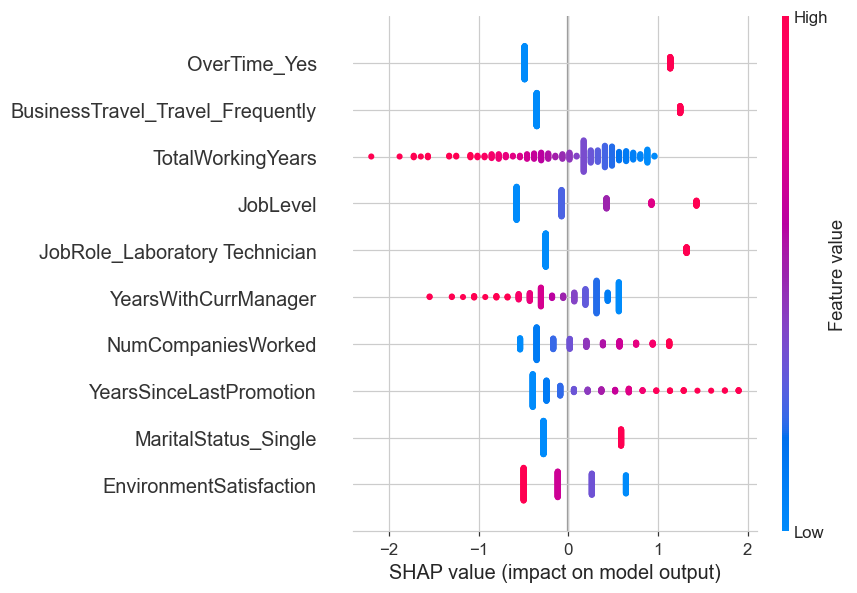

In [ ]:
# Chart 6 (Bonus): SHAP summary plot for the top 10 features
shap.summary_plot(shap_values, X_test_transformed_df, max_display=10, show=False)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart6_shap_summary.png", bbox_inches="tight")
plt.show()

**Reading this chart:** each dot is one employee in the test set. Its color
shows whether that employee's value for the feature was high (red) or low
(blue); its position left/right shows whether that pushed their predicted
risk of leaving down or up. For `OverTime`, for example, the red dots
(OverTime = Yes) cluster to the right - working overtime consistently pushes
predicted attrition risk up, which matches what we already saw in the EDA
and the plain feature-importance chart, but now at the level of individual
employees rather than just an overall ranking.

### 6. Saving the Best Model
We save the **entire pipeline** (preprocessing + model together), not just the
classifier. That means anyone loading `attrition_model.pkl` can hand it a raw,
unprocessed employee record and get a prediction straight back - no need to
remember which columns were scaled or how the categories were encoded.

In [ ]:
joblib.dump(best_pipe, "attrition_model.pkl")
print(f"Saved {best_model_name} (full pipeline) to attrition_model.pkl")

# Quick sanity check: load it back and make sure it still works
reloaded_pipe = joblib.load("attrition_model.pkl")
print("Reloaded model test ROC-AUC:", round(roc_auc_score(y_test, reloaded_pipe.predict_proba(X_test)[:, 1]), 3))

Saved Logistic Regression (full pipeline) to attrition_model.pkl
Reloaded model test ROC-AUC: 0.804


### 7. A Prediction Function for a Single Employee
This is the function the Streamlit app (see the last section) calls. Given one
employee's raw details, it returns a plain-language prediction and a
probability of leaving - no manual preprocessing required, since the pipeline
handles that internally.

In [ ]:
def predict_employee(employee: dict, model=reloaded_pipe) -> dict:
    """
    Predict attrition risk for a single employee.

    `employee` should be a dict using the SAME column names and raw category
    text as HR_Attrition.csv (e.g. {"Age": 34, "Department": "Sales", ...}) -
    no need to encode or scale anything yourself, the pipeline does that.

    Returns a dict with a plain-language prediction and the model's estimated
    probability that this employee leaves.
    """
    employee_df = pd.DataFrame([employee])
    probability_leave = model.predict_proba(employee_df)[0, 1]
    prediction = model.predict(employee_df)[0]
    return {
        "prediction": "Likely to Leave" if prediction == 1 else "Likely to Stay",
        "probability_of_leaving": round(float(probability_leave), 3),
    }

In [ ]:
# Try it on a real employee from the test set as a sanity check
sample_employee = X_test.iloc[0].to_dict()
result = predict_employee(sample_employee)

print("Sample employee (first few fields):",
      {k: sample_employee[k] for k in list(sample_employee)[:5]})
print("Prediction:", result)

Sample employee (first few fields): {'Age': 24, 'BusinessTravel': 'Non-Travel', 'DailyRate': 830, 'Department': 'Sales', 'DistanceFromHome': 13}
Prediction: {'prediction': 'Likely to Stay', 'probability_of_leaving': 0.323}


### 8. Streamlit Dashboard
The notebook above is for analysis; for day-to-day HR use, a small dashboard
is more practical. A companion file, **`app.py`**, ships alongside this
notebook and uses the exact `predict_employee()` logic and the saved
`attrition_model.pkl` to provide:

- A single-employee form to predict one person's attrition risk on demand
- Bulk CSV upload to score a whole team or department at once
- The probability of leaving for each employee, plus a Likely to Leave / Stay label
- The same Top-10 feature importance chart shown in Task 6
- A short, auto-generated plain-language recommendation per employee

Run it from a terminal in this project folder with:
```
streamlit run app.py
```

### 9. 📚 References
Here i mentioned  some documnets and References that helped me in building my project  

#### Dataset

IBM HR Analytics Employee Attrition Dataset (Kaggle) — https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

#### Data Cleaning & Preprocessing (Task 2)

pandas documentation — https://pandas.pydata.org/docs/

sklearn.preprocessing.StandardScaler — https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

sklearn.preprocessing.OneHotEncoder — https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

#### Modeling Pipeline / Leakage Fix (Task 4)

sklearn.pipeline.Pipeline — https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
sklearn.compose.ColumnTransformer — https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

sklearn.model_selection.train_test_split — https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

sklearn.linear_model.LogisticRegression — https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

sklearn.ensemble.RandomForestClassifier — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

sklearn.ensemble.GradientBoostingClassifier — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

sklearn.utils.class_weight.compute_sample_weight — https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html

#### Cross-Validation & Hyperparameter Tuning

sklearn.model_selection.StratifiedKFold / cross_val_score — https://scikit-learn.org/stable/modules/cross_validation.html

sklearn.model_selection.GridSearchCV — https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

#### Class Imbalance Comparison

imbalanced-learn (overall library docs) — https://imbalanced-learn.org/stable/
imblearn.over_sampling.SMOTE — https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

imblearn.over_sampling.RandomOverSampler — https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html

imblearn.pipeline.Pipeline — https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html

Original SMOTE paper: Chawla, N.V., et al. (2002). "SMOTE: Synthetic Minority Over-sampling Technique." Journal of Artificial Intelligence Research, 16, 321–357.

#### SHAP Explainability

SHAP documentation home — https://shap.readthedocs.io/
shap.TreeExplainer — https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html

shap.Explainer (covers LinearExplainer usage too) — https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html
Lundberg, S.M. & Lee, S.I. (2017). "A Unified Approach to Interpreting Model Predictions." NeurIPS.

#### Model Saving & Deployment

joblib persistence guide — https://joblib.readthedocs.io/en/latest/persistence.html

Streamlit documentation — https://docs.streamlit.io/

## 10. Deployment Info

This project is packaged as a small Streamlit app on top of the saved model
pipeline, so it can be run locally without touching the notebook.

**Files needed (all in the same folder):**
- `attrition_model.pkl` — the trained pipeline (preprocessing + model)
- `app.py` — the Streamlit dashboard
- `requirements.txt` — pinned dependencies

**Run it locally:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
This opens the dashboard in your browser at `http://localhost:8501`, with tabs
for single-employee prediction, bulk CSV scoring, and feature importance.

**Note on compatibility:** `scikit-learn` is pinned to `1.7.1` in
`requirements.txt`. Loading `attrition_model.pkl` with a different
scikit-learn version can raise an `AttributeError` during unpickling, since
internal estimator classes sometimes change between versions — install from
`requirements.txt` exactly rather than the latest version.

**Optional - deploying online:** the same `app.py` can be pushed to
[Streamlit Community Cloud](https://streamlit.io/cloud) (free tier) by
connecting a GitHub repo containing these same files - no code changes needed.

### My project is live on render you can check by using this link.

.Available at your primar URL https://employee-attrition-prediction-system-iymh.onrender.com